
# Вторые задания экзамена: моделирование в Python

В ноутбуке выполнены 4 задания:

1. **Билет №13** — объем эллипсоида методом Монте-Карло.
2. **Билет №17** — дискретное распределение по эмпирическим частотам.
3. **Билет №22** — имитация ежедневного спроса магазина.
4. **Билет №30** — имитация накопления средств на депозите.

Для воспроизводимости используется `seed = 42`.  
Это значит, что при повторном запуске ноутбука будут получаться те же случайные числа и те же итоговые значения.


In [1]:

import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

seed = 42
rng = np.random.default_rng(seed)

def md_table(headers, rows, float_digits=4):
    """Создает markdown-таблицу без pandas."""
    def fmt(x):
        if isinstance(x, float):
            return f"{x:.{float_digits}f}"
        return str(x)
    out = []
    out.append("| " + " | ".join(headers) + " |")
    out.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        out.append("| " + " | ".join(fmt(x) for x in row) + " |")
    return "\n".join(out)

print("Seed:", seed)


Matplotlib is building the font cache; this may take a moment.


Seed: 42



## Билет №13 — объем эллипсоида методом Монте-Карло

Нужно оценить объем эллипсоида

\[
\frac{x^2}{4} + \frac{y^2}{9} + \frac{z^2}{16} \leq 1.
\]

Полуоси эллипсоида:

\[
a = 2,\quad b = 3,\quad c = 4.
\]

Описывающий параллелепипед:

\[
x \in [-2;2],\quad y \in [-3;3],\quad z \in [-4;4].
\]

Его объем:

\[
V_{box} = 4 \cdot 6 \cdot 8 = 192.
\]

Идея метода Монте-Карло:

\[
\hat V = V_{box} \cdot \frac{m}{N},
\]

где:

- \(N\) — число случайных точек;
- \(m\) — число точек, попавших внутрь эллипсоида;
- \(\frac{m}{N}\) — оценка вероятности попадания точки внутрь.

Точное значение:

\[
V = \frac{4}{3}\pi abc = \frac{4}{3}\pi \cdot 2 \cdot 3 \cdot 4.
\]


In [2]:

# Билет 13
N13 = 2000
a, b, c = 2, 3, 4

x = rng.uniform(-a, a, N13)
y = rng.uniform(-b, b, N13)
z = rng.uniform(-c, c, N13)

inside = (x**2/a**2 + y**2/b**2 + z**2/c**2 <= 1).astype(int)

V_box = (2*a) * (2*b) * (2*c)
p_hat = inside.mean()
V_est = V_box * p_hat
V_exact = 4/3 * math.pi * a * b * c

std_error = V_box * math.sqrt(p_hat * (1 - p_hat) / N13)
ci_low = V_est - 1.96 * std_error
ci_high = V_est + 1.96 * std_error

abs_error = abs(V_est - V_exact)
rel_error = abs_error / V_exact

rows13 = [
    ["Число точек N", N13],
    ["Объем параллелепипеда", V_box],
    ["Доля попаданий p̂", p_hat],
    ["Оценка объема V̂", V_est],
    ["Точное значение V", V_exact],
    ["Абсолютная погрешность", abs_error],
    ["Относительная погрешность", rel_error],
    ["Стандартная ошибка", std_error],
    ["95% ДИ, нижняя граница", ci_low],
    ["95% ДИ, верхняя граница", ci_high],
]
display(Markdown(md_table(["Показатель", "Значение"], rows13, float_digits=6)))


| Показатель | Значение |
| --- | --- |
| Число точек N | 2000 |
| Объем параллелепипеда | 192 |
| Доля попаданий p̂ | 0.523000 |
| Оценка объема V̂ | 100.416000 |
| Точное значение V | 100.530965 |
| Абсолютная погрешность | 0.114965 |
| Относительная погрешность | 0.001144 |
| Стандартная ошибка | 2.144353 |
| 95% ДИ, нижняя граница | 96.213068 |
| 95% ДИ, верхняя граница | 104.618932 |

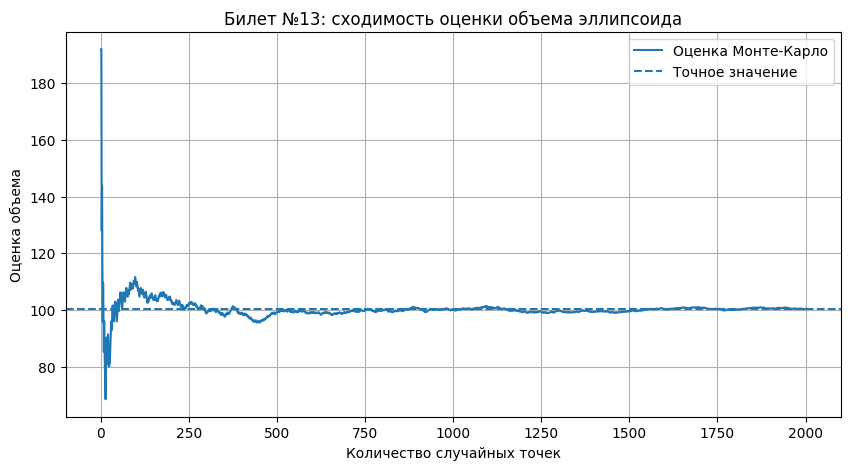

In [3]:

# График сходимости оценки объема
n = np.arange(1, N13 + 1)
cum_est = V_box * np.cumsum(inside) / n

plt.figure(figsize=(10, 5))
plt.plot(n, cum_est, label="Оценка Монте-Карло")
plt.axhline(V_exact, linestyle="--", label="Точное значение")
plt.xlabel("Количество случайных точек")
plt.ylabel("Оценка объема")
plt.title("Билет №13: сходимость оценки объема эллипсоида")
plt.legend()
plt.grid(True)
plt.show()



### Вывод по билету №13

Оценка объема получилась близкой к точному значению.  
Точное значение попадает в доверительный интервал, значит результат моделирования можно считать адекватным для выбранного числа точек.

При увеличении числа случайных точек график сходимости стабилизируется около точного значения.



## Билет №17 — дискретное распределение по эмпирическим частотам

Даны значения случайной величины и частоты:

| Значение | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---:|---:|---:|---:|---:|---:|
| Частота | 18 | 32 | 51 | 48 | 29 | 22 |

Сначала вычисляем вероятности:

\[
p_i = \frac{n_i}{\sum n_i}.
\]

Затем строим функцию распределения:

\[
F(x_i) = \sum_{j=1}^{i} p_j.
\]

Для генерации случайной величины берется равномерное случайное число \(u \in [0;1)\).  
Далее выбирается значение, в интервал которого попало \(u\).


In [4]:

# Билет 17
values17 = np.array([0, 1, 2, 3, 4, 5])
freq17 = np.array([18, 32, 51, 48, 29, 22])

prob17 = freq17 / freq17.sum()
cdf17 = np.cumsum(prob17)
interval_start17 = np.concatenate(([0], cdf17[:-1]))
interval_end17 = cdf17

dist17_rows = []
for v, f, p, F, left, right in zip(values17, freq17, prob17, cdf17, interval_start17, interval_end17):
    dist17_rows.append([v, f, p, F, left, right])

display(Markdown(md_table(
    ["Значение", "Частота", "Вероятность", "F(x)", "Начало интервала", "Конец интервала"],
    dist17_rows,
    float_digits=3
)))

N17 = 2000
u17 = rng.random(N17)
sample17 = values17[np.searchsorted(cdf17, u17, side="right")]

sim_counts17 = np.array([(sample17 == v).sum() for v in values17])
sim_prob17 = sim_counts17 / N17
abs_dev17 = np.abs(sim_prob17 - prob17)

compare17_rows = []
for v, p, sc, sp, dev in zip(values17, prob17, sim_counts17, sim_prob17, abs_dev17):
    compare17_rows.append([v, p, sc, sp, dev])

display(Markdown(md_table(
    ["Значение", "Теор. вероятность", "Сим. частота", "Сим. вероятность", "Абс. отклонение"],
    compare17_rows,
    float_digits=4
)))

chi2_17 = np.sum((sim_counts17 - N17 * prob17) ** 2 / (N17 * prob17))
mean_abs_dev17 = abs_dev17.mean()

print(f"Среднее абсолютное отклонение вероятностей: {mean_abs_dev17:.4f}")
print(f"Статистика χ² для сравнения частот: {chi2_17:.4f}")


| Значение | Частота | Вероятность | F(x) | Начало интервала | Конец интервала |
| --- | --- | --- | --- | --- | --- |
| 0 | 18 | 0.090 | 0.090 | 0.000 | 0.090 |
| 1 | 32 | 0.160 | 0.250 | 0.090 | 0.250 |
| 2 | 51 | 0.255 | 0.505 | 0.250 | 0.505 |
| 3 | 48 | 0.240 | 0.745 | 0.505 | 0.745 |
| 4 | 29 | 0.145 | 0.890 | 0.745 | 0.890 |
| 5 | 22 | 0.110 | 1.000 | 0.890 | 1.000 |

| Значение | Теор. вероятность | Сим. частота | Сим. вероятность | Абс. отклонение |
| --- | --- | --- | --- | --- |
| 0 | 0.0900 | 177 | 0.0885 | 0.0015 |
| 1 | 0.1600 | 318 | 0.1590 | 0.0010 |
| 2 | 0.2550 | 513 | 0.2565 | 0.0015 |
| 3 | 0.2400 | 501 | 0.2505 | 0.0105 |
| 4 | 0.1450 | 270 | 0.1350 | 0.0100 |
| 5 | 0.1100 | 221 | 0.1105 | 0.0005 |

Среднее абсолютное отклонение вероятностей: 0.0042
Статистика χ² для сравнения частот: 2.3828


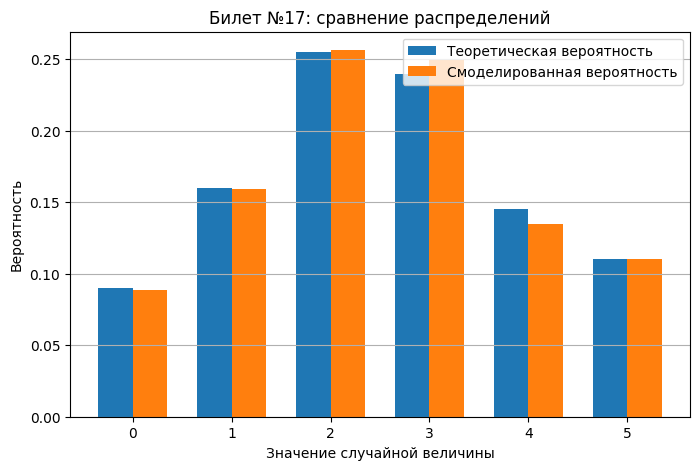

In [5]:

# Сравнение теоретических и смоделированных вероятностей
width = 0.35
positions = np.arange(len(values17))

plt.figure(figsize=(8, 5))
plt.bar(positions - width/2, prob17, width, label="Теоретическая вероятность")
plt.bar(positions + width/2, sim_prob17, width, label="Смоделированная вероятность")
plt.xticks(positions, values17)
plt.xlabel("Значение случайной величины")
plt.ylabel("Вероятность")
plt.title("Билет №17: сравнение распределений")
plt.legend()
plt.grid(True, axis="y")
plt.show()



### Вывод по билету №17

Смоделированные вероятности близки к теоретическим вероятностям, построенным по эмпирическим частотам.  
Небольшие отклонения объясняются случайностью имитационного эксперимента.  
При увеличении числа сгенерированных значений гистограмма будет становиться ближе к исходному распределению.



## Билет №22 — моделирование ежедневного спроса

Дано распределение спроса магазина «Все по 100» за 200 дней:

| Спрос, ед./день | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---:|---:|---:|---:|---:|---:|
| Число дней | 15 | 25 | 45 | 55 | 35 | 25 |

Нужно:

1. построить функцию распределения;
2. смоделировать спрос на 20 дней;
3. провести 20 экспериментов;
4. оценить средний ежедневный спрос;
5. сравнить его с теоретическим математическим ожиданием.

Теоретическое математическое ожидание:

\[
E(X) = \sum x_i p_i.
\]


In [6]:

# Билет 22
values22 = np.array([0, 1, 2, 3, 4, 5])
freq22 = np.array([15, 25, 45, 55, 35, 25])

prob22 = freq22 / freq22.sum()
cdf22 = np.cumsum(prob22)
interval_start22 = np.concatenate(([0], cdf22[:-1]))
interval_end22 = cdf22

dist22_rows = []
for v, f, p, F, left, right in zip(values22, freq22, prob22, cdf22, interval_start22, interval_end22):
    dist22_rows.append([v, f, p, F, left, right])

display(Markdown(md_table(
    ["Спрос", "Число дней", "Вероятность", "F(x)", "Начало интервала", "Конец интервала"],
    dist22_rows,
    float_digits=3
)))

E22 = np.sum(values22 * prob22)

experiments22 = 20
days22 = 20

u22 = rng.random((experiments22, days22))
demand_sim = values22[np.searchsorted(cdf22, u22, side="right")]

exp_means22 = demand_sim.mean(axis=1)
overall_mean22 = demand_sim.mean()
diff22 = overall_mean22 - E22

rows22 = [
    ["Теоретическое математическое ожидание E(X)", E22],
    ["Средний спрос по всем экспериментам", overall_mean22],
    ["Разница имитация − теория", diff22],
]

display(Markdown(md_table(["Показатель", "Значение"], rows22, float_digits=4)))

first_5_rows = []
for i in range(5):
    first_5_rows.append([i + 1] + list(demand_sim[i]) + [exp_means22[i]])

display(Markdown("Первые 5 экспериментов:"))
display(Markdown(md_table(
    ["Эксп."] + [f"День {i}" for i in range(1, 21)] + ["Среднее"],
    first_5_rows,
    float_digits=2
)))


| Спрос | Число дней | Вероятность | F(x) | Начало интервала | Конец интервала |
| --- | --- | --- | --- | --- | --- |
| 0 | 15 | 0.075 | 0.075 | 0.000 | 0.075 |
| 1 | 25 | 0.125 | 0.200 | 0.075 | 0.200 |
| 2 | 45 | 0.225 | 0.425 | 0.200 | 0.425 |
| 3 | 55 | 0.275 | 0.700 | 0.425 | 0.700 |
| 4 | 35 | 0.175 | 0.875 | 0.700 | 0.875 |
| 5 | 25 | 0.125 | 1.000 | 0.875 | 1.000 |

| Показатель | Значение |
| --- | --- |
| Теоретическое математическое ожидание E(X) | 2.7250 |
| Средний спрос по всем экспериментам | 2.7950 |
| Разница имитация − теория | 0.0700 |

Первые 5 экспериментов:

| Эксп. | День 1 | День 2 | День 3 | День 4 | День 5 | День 6 | День 7 | День 8 | День 9 | День 10 | День 11 | День 12 | День 13 | День 14 | День 15 | День 16 | День 17 | День 18 | День 19 | День 20 | Среднее |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 3 | 5 | 2 | 0 | 4 | 4 | 3 | 4 | 4 | 3 | 5 | 4 | 3 | 2 | 0 | 2 | 4 | 4 | 2 | 3 | 3.05 |
| 2 | 1 | 2 | 5 | 2 | 2 | 3 | 2 | 4 | 5 | 3 | 3 | 2 | 3 | 2 | 0 | 4 | 3 | 3 | 1 | 4 | 2.70 |
| 3 | 1 | 2 | 4 | 3 | 5 | 2 | 4 | 5 | 3 | 3 | 2 | 4 | 5 | 4 | 5 | 3 | 3 | 2 | 4 | 5 | 3.45 |
| 4 | 3 | 2 | 3 | 4 | 5 | 1 | 1 | 2 | 1 | 5 | 2 | 3 | 2 | 3 | 5 | 3 | 0 | 2 | 5 | 5 | 2.85 |
| 5 | 2 | 3 | 1 | 3 | 1 | 4 | 5 | 1 | 3 | 1 | 2 | 0 | 2 | 5 | 0 | 4 | 1 | 3 | 3 | 5 | 2.45 |

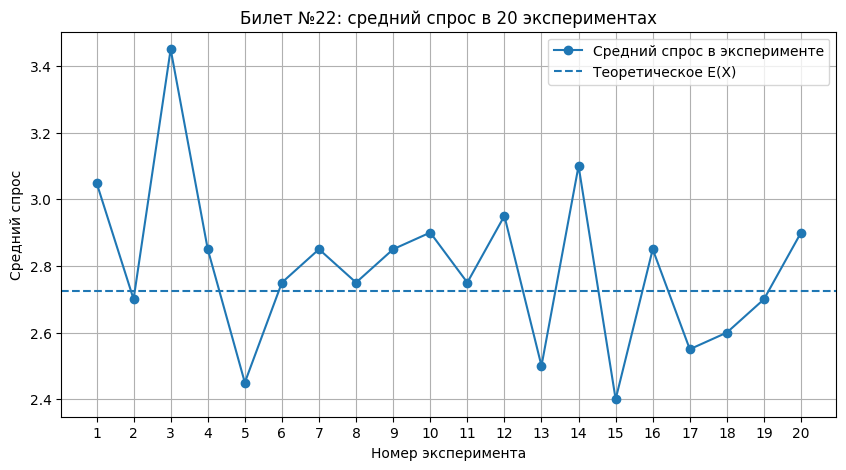

In [7]:

# График средних значений по экспериментам
exp_nums = np.arange(1, experiments22 + 1)

plt.figure(figsize=(10, 5))
plt.plot(exp_nums, exp_means22, marker="o", label="Средний спрос в эксперименте")
plt.axhline(E22, linestyle="--", label="Теоретическое E(X)")
plt.xlabel("Номер эксперимента")
plt.ylabel("Средний спрос")
plt.title("Билет №22: средний спрос в 20 экспериментах")
plt.xticks(exp_nums)
plt.legend()
plt.grid(True)
plt.show()



### Вывод по билету №22

Средний спрос, полученный в имитации, близок к теоретическому математическому ожиданию.  
Разница возникает из-за того, что число экспериментов и дней ограничено: всего моделируется \(20 \cdot 20 = 400\) дней.  
Если увеличить число экспериментов или число дней, имитационное среднее будет ближе к теоретическому значению.



## Билет №30 — моделирование накопления средств на депозите

Начальная сумма:

\[
S_0 = 100000.
\]

Месячная ставка задается дискретным распределением:

| Ставка, % | Вероятность |
|---:|---:|
| 0.5 | 0.2 |
| 0.7 | 0.3 |
| 0.9 | 0.3 |
| 1.1 | 0.2 |

Пополнение задается дискретным распределением:

| Пополнение, руб. | Вероятность |
|---:|---:|
| 5000 | 0.25 |
| 10000 | 0.35 |
| 15000 | 0.25 |
| 20000 | 0.15 |

Формула перехода от месяца к месяцу:

\[
S_t = S_{t-1}\left(1 + \frac{r_t}{100}\right) + P_t,
\]

где:

- \(S_t\) — баланс после месяца \(t\);
- \(r_t\) — случайная процентная ставка в процентах;
- \(P_t\) — случайное пополнение.


In [8]:

# Билет 30
initial = 100_000
months30 = 24
experiments30 = 20

rates_values_percent = np.array([0.5, 0.7, 0.9, 1.1])
rates_prob = np.array([0.2, 0.3, 0.3, 0.2])
rates_cdf = np.cumsum(rates_prob)

contrib_values = np.array([5000, 10000, 15000, 20000])
contrib_prob = np.array([0.25, 0.35, 0.25, 0.15])
contrib_cdf = np.cumsum(contrib_prob)

u_rate = rng.random((experiments30, months30))
u_contrib = rng.random((experiments30, months30))

rates_sim_percent = rates_values_percent[np.searchsorted(rates_cdf, u_rate, side="right")]
contrib_sim = contrib_values[np.searchsorted(contrib_cdf, u_contrib, side="right")]

balances = np.zeros((experiments30, months30 + 1))
balances[:, 0] = initial

for exp in range(experiments30):
    for month in range(1, months30 + 1):
        rate = rates_sim_percent[exp, month - 1]
        contribution = contrib_sim[exp, month - 1]
        balances[exp, month] = balances[exp, month - 1] * (1 + rate / 100) + contribution

final_balances = balances[:, -1]
avg_final = final_balances.mean()
std_final = final_balances.std(ddof=1)
std_error_final = std_final / math.sqrt(experiments30)
ci_final_low = avg_final - 1.96 * std_error_final
ci_final_high = avg_final + 1.96 * std_error_final

rows30 = [
    ["Средняя итоговая сумма", avg_final],
    ["Стандартное отклонение итоговой суммы", std_final],
    ["Стандартная ошибка", std_error_final],
    ["95% ДИ, нижняя граница", ci_final_low],
    ["95% ДИ, верхняя граница", ci_final_high],
]

display(Markdown(md_table(["Показатель", "Значение"], rows30, float_digits=2)))

first_5_final = [[i + 1, final_balances[i]] for i in range(5)]
display(Markdown("Итоговые суммы в первых 5 экспериментах:"))
display(Markdown(md_table(["Эксперимент", "Итоговая сумма"], first_5_final, float_digits=2)))


| Показатель | Значение |
| --- | --- |
| Средняя итоговая сумма | 425625.59 |
| Стандартное отклонение итоговой суммы | 28444.28 |
| Стандартная ошибка | 6360.33 |
| 95% ДИ, нижняя граница | 413159.34 |
| 95% ДИ, верхняя граница | 438091.85 |

Итоговые суммы в первых 5 экспериментах:

| Эксперимент | Итоговая сумма |
| --- | --- |
| 1 | 401770.80 |
| 2 | 422160.15 |
| 3 | 411760.31 |
| 4 | 421818.68 |
| 5 | 456578.89 |

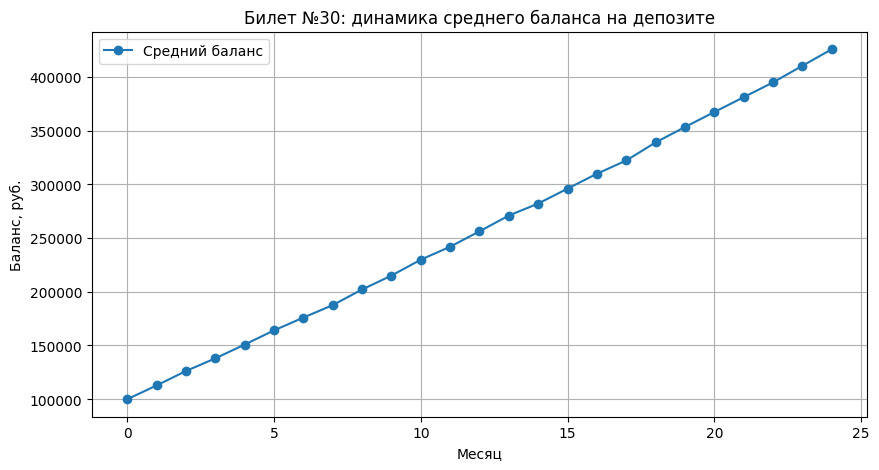

In [9]:

# График динамики среднего баланса
avg_balance_by_month = balances.mean(axis=0)
months = np.arange(0, months30 + 1)

plt.figure(figsize=(10, 5))
plt.plot(months, avg_balance_by_month, marker="o", label="Средний баланс")
plt.xlabel("Месяц")
plt.ylabel("Баланс, руб.")
plt.title("Билет №30: динамика среднего баланса на депозите")
plt.legend()
plt.grid(True)
plt.show()



### Вывод по билету №30

Баланс в среднем растет каждый месяц за счет двух факторов:

1. начисления процентов;
2. ежемесячных пополнений.

Итоговая сумма различается по экспериментам, потому что каждый раз случайно выбираются ставки и пополнения.  
Средняя итоговая сумма по 20 экспериментам является имитационной оценкой ожидаемого результата за 24 месяца.
